In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import numpy as np
from scipy.stats import mannwhitneyu

from matplotlib.transforms import blended_transform_factory
import matplotlib.patches as mpatches
from statsmodels.stats.multitest import multipletests

from matplotlib.patches import FancyArrowPatch

In [3]:
# Read in the clustering data which Michael sent me
files = pd.read_csv('../data/Radius_100_patient_id_edited.csv')

In [5]:
# Add clinical information to the dataframe
outcomes = pd.read_excel('../data/Outcomes_master_simplified_updatedJan24_patient_updated.xlsx')
outcomes['Outcome_C6_revised_Vid'] = outcomes['Outcome_C6_revised_Vid'].replace('non-responder_2', 'Non-responder').replace('responder_1', 'Responder')
outcomes['Outcome_C12_CC486'] = outcomes['Outcome_C12_CC486'].replace('non-responder_2', 'Non-responder').replace('responder_1', 'Responder')

outcomes_6 = dict(zip(outcomes['PID'], outcomes['Outcome_C6_revised_Vid']))
outcomes_12 = dict(zip(outcomes['PID'], outcomes['Outcome_C12_CC486']))
diagnosis = dict(zip(outcomes['PID'], outcomes['Diagnosis']))


files['diagnosis'] = files['PID'].map(diagnosis)
files['outcomes_6'] = files['PID'].map(outcomes_6)
files['outcomes_12'] = files['PID'].map(outcomes_12)

In [7]:
# Delete the patient P02 as it has few cells. This patient 
files = files.loc[files['PID'] != 'P02', :]
print(len(files['pid_tp'].unique()))
files = files.loc[~((files['PID'] == 'P04') & (files['tp'] == 'C12')), :]
files = files.loc[~((files['PID'] == 'P18') & (files['tp'] == 'Prog')), :]
files = files.loc[~((files['PID'] == 'P03') & (files['tp'] == 'C12')), :]
print(len(files['pid_tp'].unique()))

32
29


In [9]:
# Make a dictionary which maps each patient to a response timepoint. This is because some patients are missing a timepoint
# and switch clinical responses. (i.e a patient is a responder at C7 but is missing that trephine and I have a C12). 

b = files[['PID', 'tp']].drop_duplicates()

patient_response_dict = {}
for i in b['PID'].unique():
    c = b.loc[b['PID'] == i, :]
    #print(c['tp'].unique())
    if 'C12' in c['tp'].to_list():
        patient_response_dict[i] = outcomes_12[i]
    elif 'Prog' in c['tp'].to_list():
        patient_response_dict[i] = 'Non-responder'
    else:
        patient_response_dict[i] = outcomes_6[i]

In [11]:
# Create a dictionary which details the number of cells in each cluster for each patient
df_dict = {}
for i in files['PID'].unique():
    a = files.loc[files['PID'] == i, :]
    df_dict[i] = {}  #
    for e in a['tp'].unique():
        data = a.loc[a['tp'] == e, :]
        df_dict[i][e] = data['Leiden_Group'].value_counts(normalize = True) * 100


In [13]:
# Turn my dictionaries into a dataframe. df_dict is a multilevel index
df = pd.DataFrame({(alias, tp): counts 
                   for alias, tp_dict1 in df_dict.items() 
                   for tp, counts in tp_dict1.items()})
df.columns = pd.MultiIndex.from_tuples(df.columns, names=['alias', 'tp'])
df.columns = ['_'.join(map(str, col)) for col in df.columns]
df = df.fillna(0).T
df.head()

Leiden_Group,0,1,2,3,4,5,6,7,8,9,...,49,50,51,52,53,54,55,56,57,58
P08_C1,1.558911,0.474026,8.361433,0.039095,4.588770,5.419538,5.116552,0.327420,6.299174,3.093388,...,0.009774,0.0,0.0,0.009774,0.004887,0.014661,0.000000,0.000000,0.000000,0.000000
P08_C7,0.219546,0.131728,4.278008,0.000000,9.183289,1.875549,0.796638,0.514365,14.464935,7.282650,...,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
P24_C1,5.580866,0.004218,1.434236,0.000000,1.501730,1.387834,0.890070,0.105459,0.168734,1.143171,...,0.004218,0.0,0.0,0.008437,0.033747,0.012655,0.012655,0.033747,0.050620,0.016873
P19_C1,2.362156,0.055508,1.276674,0.000000,4.570125,6.784261,0.585913,1.171827,4.372764,2.534846,...,0.000000,0.0,0.0,0.006168,0.000000,0.000000,0.018503,0.000000,0.000000,0.000000
P12_C12,3.973805,0.171381,1.986903,0.000000,3.773164,1.469974,2.162463,0.124007,6.775812,2.487112,...,0.006967,0.0,0.0,0.000000,0.001393,0.016720,0.001393,0.001393,0.001393,0.000000


In [15]:
# Add clinical information to each df to specify whether an observation is a pre or a post timepoint
df['response'] = df.index.str.split('_').str[0].map(patient_response_dict)

timepoint = []
for i in df.index.str.split('_').str[1]:
    if ('C12' in i) | ('C7' in i) | ('Prog' in i):
        timepoint.append('post')
    else:
        timepoint.append('pre')
df['timepoint'] = timepoint

In [17]:
# Read in the p-values which was produced by Jake on 2026_03_06. These are the updated p-values for the non-responder
# samples for diagnosis versus non-response
nr = pd.read_excel('../data/2026_03_06_p_values_from_jake.xlsx')
nr = nr.sort_values('p_value')
nr['Class'] = 'Non-responder'

#nr = nr.loc[nr['p_value'] <= 0.1, :]
nr['Cluster']

14    14
15    15
26    26
35    35
21    21
24    24
23    23
7      7
5      5
20    20
34    34
1      1
31    31
6      6
12    12
28    28
29    29
33    33
18    18
9      9
17    17
22    22
39    39
19    19
4      4
43    43
3      3
41    41
13    13
0      0
44    44
25    25
2      2
42    42
27    27
37    37
40    40
16    16
38    38
36    36
11    11
49    49
30    30
45    45
54    54
32    32
10    10
46    46
55    55
50    50
47    47
52    52
53    53
56    56
58    58
8      8
57    57
48    48
51    51
Name: Cluster, dtype: int64

In [19]:
# Read in the p-value which Jake sent me on the 14th of February
p_val = pd.read_excel('../data/2026_02_14_p_values_from_jake.xlsx', sheet_name= 'Responders_diagnosis_v_response')
p_val['class'] = 'Responder'
pvals = p_val['p_value'].to_list()  # your list

p_val = p_val.sort_values('p_value', ascending = True)
p_val.head(10)

,Cluster,p_value,Estimate,class
30,30,0.0001,Neg,Responder
8,8,0.0001,Neg,Responder
38,38,0.0002,Neg,Responder
28,28,0.0182,Pos,Responder
16,16,0.0201,Pos,Responder
43,43,0.0208,Neg,Responder
19,19,0.0219,Pos,Responder
12,12,0.0224,Neg,Responder
15,15,0.0384,Pos,Responder
42,42,0.0448,Neg,Responder


In [21]:
import numpy as np
from matplotlib.patches import Polygon

def add_significance_stars(ax, x, y, p_value, is_responder, cluster, outcome_params, line_y, fontsize=8):
    thresholds = [(0.0001, '****'), (0.001, '***'), (0.01, '**'), (0.05, '*')]
    stars = next((s for threshold, s in thresholds if p_value < threshold), None)
    if not stars:
        return
    bar_width = 0.35
    group_key = 'Responder' if is_responder else 'Non-responder'
    multiplier = 1 if is_responder else -1
    y_limit = ax.get_ylim()[1]
    star_y = line_y + (y_limit * 0.15 * multiplier)
    # Look up Estimate
    estimate = outcome_params[group_key]['df']
    estimate = estimate.loc[estimate['Cluster'] == cluster, 'Estimate']
    estimate = estimate.values[0] if not estimate.empty else 'Pos'
    
    # Horizontal line
    line_xmin = x - bar_width/2 - 0.025
    line_xmax = x + bar_width/2 + 0.025
    ax.hlines(y=line_y, xmin=line_xmin, xmax=line_xmax,
              colors='black', linewidth=0.8, clip_on=False)
    arrow_dx = bar_width * 0.5
    arrow_dy = y_limit * 0.15 * multiplier * (1 if estimate == 'Neg' else -1)
    line_center = x

    ax.text(x, star_y, stars, ha='center', va='center', fontsize=fontsize)

In [23]:
# Read in the least mean squares estimate from Jake
nr_estimate = pd.read_excel('../data/2026_03_13_least_square_mean_estimates.xlsx', sheet_name='Diagnosis_v_NR')
nr_estimate['outcome'] = 'Non-responder'

r_estimate = pd.read_excel('../data/2026_03_13_least_square_mean_estimates.xlsx', sheet_name='Diagnosis_v_R')
r_estimate['outcome'] = 'Responder'

combined = pd.concat([nr_estimate, r_estimate], ignore_index=True)

# Rename to match your existing plotting code
combined = combined.rename(columns={'Clinical_measurement': 'timepoint'})

tp = []
for x in combined['timepoint']:
    if x == 'Diagnosis':
        tp.append('pre')
    else:
        tp.append('post')

combined['time'] = tp

In [25]:
# Read in cell type colors 
colors = pd.read_excel('../data/cell_type_colors.xlsx', sheet_name='2026_02_23')
colors.loc[len(colors)] = ['Endo', '#FFD94AFF']
colors_dict = dict(zip(colors['Cell_Type'], colors['Color']))
colors_dict

# Read in cluster dataframe which details the focal cell identity of any cluster
cluster = pd.read_excel('../data/2026_02_27_cluster_to_cell_type.xlsx')

# Create a dictionary which maps the clusters to a color
cluster_dict = {}
for x, y in zip(cluster['Cluster'], cluster['Cell_type']):
    cluster_dict[x] = colors_dict[y]

In [27]:
# Order the categories list to allow for easy plotting

# Create a list of clusters to plot
categories = [8, 30, 38, 32, 36, 40]

order = ['CD8_T','CD4_T', 
         'Stromal','HSPC',
 'Endothelial',
 'Endo', 'Mixed']

cluster_dict1 = dict(zip(cluster['Cluster'], cluster['Cell_type']))
cluster_dict1

list_ordered = []
for i in order:
    for x, y in cluster_dict1.items():
        if (y == i) and (x in categories):
            list_ordered.append(x)
            print(x, i)

8 Stromal
30 Stromal
32 Stromal
36 Stromal
38 Stromal
40 Stromal


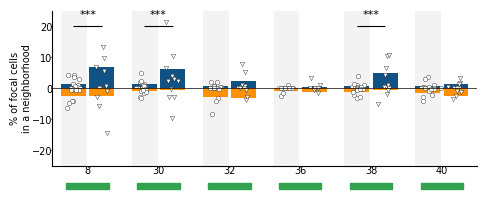

In [49]:
# Make a graph which shows the change in cell type abundance from C1 to response

fig, ax = plt.subplots(figsize=(4.7, 1.8))
ax.set_ylim(-25, 25)
plt.rcParams['svg.fonttype'] = 'none' # export font as editable text
plt.rcParams['pdf.fonttype'] = 'truetype' # export font as editable text


# Define colors for different times
colors = {'Non-responder': '#fe9003', 'Responder': '#115284'}
markers = {'pre': 'o', 'post': 'v'}

# Define the categories and their positions on the x-axis

categories = list_ordered

x_positions = np.arange(len(categories))

# Set the width of each bar
bar_width = 0.35

# Plot bars for each outcome and time
for outcome in ['Responder', 'Non-responder']:
    multiplier = 1 if outcome == 'Responder' else -1
    
    for time in ['pre', 'post']:
        offset = -bar_width/2 -0.025 if time == 'pre' else bar_width/2 +0.025 
        
        values = combined[(combined['outcome'] == outcome) & (combined['time'] == time)].set_index('Cluster_Neighborhood')['Exponentiated'].loc[categories] * 100
        
        # Draw hatched background bars for pre samples
        if time == 'pre':
            hatch_height = 25 * multiplier
            ax.bar(x_positions + offset, hatch_height, bar_width,
                   facecolor='lightgrey',  # Light grey background
                   edgecolor='lightgrey',  # Edge for the hatch
                   alpha=0.25,
                   #hatch='xxxxxx',
                   linewidth=0.5,
                   zorder=1)
            
        ax.bar(x_positions + offset, values * multiplier, bar_width, 
               #color = colors[outcome], 
               facecolor = colors[outcome],
               edgecolor = None, 
               alpha=1, 
               label=f'{outcome} - {time}')

        # Add individual data points with jitter
        for category in categories:
            subset = df[(df['response'] == outcome) & (df['timepoint'] == time)]
            category_data = subset[category]  # replaces the groupby loop
            x_jitter = np.random.normal(0, 0.05, size=len(category_data))
            ax.scatter(x_positions[categories.index(category)] + offset + x_jitter,
                       category_data * multiplier,
                       marker=markers[time],
                       facecolor='white',
                       edgecolor='black', linewidth=0.25,
                       alpha=1, s=10)

# Add a horizontal line to the graph
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# # Set labels and title 
ax.set_xticks(x_positions)
ax.set_xticklabels(labels = categories)
ax.set_xlim(-0.5, len(categories) - 0.5)
ax.tick_params(axis='both', labelsize=7, pad = -1, length = 1)    
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylabel('% of focal cells'+ '\n' + 'in a neighborhood', fontsize = 7, labelpad = 0.1)

# #Add legend
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', label='Pre',
                              markerfacecolor= 'white', markeredgewidth=1, markeredgecolor = 'black', markersize=5),
                   plt.Line2D([0], [0], marker='v', color='w', label='Post',
                             markerfacecolor= 'white', markeredgewidth=1, markeredgecolor = 'black',  markersize=5),
                   plt.Line2D([0], [0], linestyle='', color='blue', label='Responder'),
                   plt.Line2D([0], [0], linestyle='', color='red', label='Non-responder')]


# labelcolor = ['black', 'black', '#115284', '#fe9003']
# ax.legend(handles=legend_elements, ncol = 2, columnspacing = -1, handletextpad = -0.25,
#           loc='upper right', labelcolor = labelcolor, fontsize = 7,  frameon = False)

# Specify which df
outcome_params = {
    'Responder':     {'df': p_val, 'y_tri': 20,  'y_star': 1,   'is_responder': True},
    'Non-responder': {'df': nr,    'y_tri': -20, 'y_star': 0.2, 'is_responder': False},
}

for outcome, params in outcome_params.items():
    df_out = params['df']
    y_limit = ax.get_ylim()[1]
    multiplier = 1 if params['is_responder'] else -1
    line_y = y_limit * 0.80 * multiplier   # fixed for all bars in this group

    for i, category in enumerate(categories):
        if (df_out['Cluster'] == category).any():
            row = df_out.loc[df_out['Cluster'] == category]
            p_value  = row['p_value'].values[0]

            add_significance_stars(ax, x_positions[i], params['y_star'], p_value,
                                   is_responder=params['is_responder'],
                                   cluster=category,
                                   outcome_params=outcome_params,
                                   line_y=line_y)
            
# Add a box to the bottom of each graph to confirm the identity of the focal cell for each cluster
transform = blended_transform_factory(ax.transData, ax.transAxes)

box_width = 0.6   
box_height = 0.04
box_y = -0.15  

# Add a box at the bottom of each graph to indicate the cluster type
for i, category in enumerate(categories):
    color = cluster_dict.get(category)  # your dict mapping category -> color
    if color:
        rect = mpatches.FancyBboxPatch(
            (x_positions[i] - box_width / 2, box_y),
            box_width, box_height,
            boxstyle="square,pad=0",
            transform=transform,
            color=color,
            clip_on=False
        )
        ax.add_patch(rect)

fig.set_size_inches(4.7, 1.8)
fig.tight_layout(pad=0.1)

fig.savefig('../results/pre_v_pos_graphs_stromal_cells_clinical_observation.pdf', bbox_inches = 'tight', pad_inches=0.01,  dpi = 600)

In [53]:
p_val

,Cluster,p_value,Estimate,class
30,30,0.0001,Neg,Responder
8,8,0.0001,Neg,Responder
38,38,0.0002,Neg,Responder
28,28,0.0182,Pos,Responder
16,16,0.0201,Pos,Responder
43,43,0.0208,Neg,Responder
19,19,0.0219,Pos,Responder
12,12,0.0224,Neg,Responder
15,15,0.0384,Pos,Responder
42,42,0.0448,Neg,Responder


In [61]:
nr

,Cluster,p_value,Estimate,Class
14,14,0.0001,Neg,Non-responder
15,15,0.0001,Neg,Non-responder
26,26,0.0002,Neg,Non-responder
35,35,0.0003,Neg,Non-responder
21,21,0.0004,Neg,Non-responder
24,24,0.0011,Neg,Non-responder
23,23,0.0023,Neg,Non-responder
7,7,0.0043,Neg,Non-responder
5,5,0.0053,Pos,Non-responder
20,20,0.0065,Pos,Non-responder
